In [2]:
devtools::load_all("/home/tangyh/script/Modsite")

ℹ Loading modsite
Warning message:
“package ‘testthat’ was built under R version 4.4.3”


In [11]:
library("survival")
library(ggplot2)
library(ggrepel)
library(foreach)
library(doParallel)

Warning message:
“package ‘foreach’ was built under R version 4.4.3”
Warning message:
“package ‘doParallel’ was built under R version 4.4.3”
Loading required package: iterators

Warning message:
“package ‘iterators’ was built under R version 4.4.3”
Loading required package: parallel



In [138]:
flip_strand <- function(x) {
  x <- as.character(x)
  out <- x
  out[x == "+"] <- "-"
  out[x == "-"] <- "+"
  out
}


annotate_snc_reference <- function(sites_df, gtf_file) {
  stopifnot(is.data.frame(sites_df))
  stopifnot(all(c("chrom", "pos") %in% colnames(sites_df)))

  gtf <- read.delim(
    gtf_file,
    sep = "\t",
    header = FALSE,
    quote = "",
    comment.char = "#",
    stringsAsFactors = FALSE
  )
  if (ncol(gtf) < 9) stop("The GTF file must contain at least 9 columns.", call. = FALSE)

  colnames(gtf)[1:9] <- c(
    "ref_name", "source", "feature", "ref_start", "ref_end",
    "score", "ref_strand", "phase", "attributes"
  )

  extract_attr <- function(x, key) {
    pat <- paste0(key, ' "([^"]*)"')
    m <- regexec(pat, x)
    out <- regmatches(x, m)
    sapply(out, function(z) if (length(z) >= 2) z[2] else NA_character_)
  }

  ann_df <- data.frame(
    chrom      = gtf$ref_name,
    gene_type  = extract_attr(gtf$attributes, "type"),       # 原 rna_type
    tx_name    = extract_attr(gtf$attributes, "location"),   # 原 location
    gene_id    = extract_attr(gtf$attributes, "geneID"),
    gene_name  = extract_attr(gtf$attributes, "geneName"),
    stringsAsFactors = FALSE
  )

  # 保留每条染色体的去重行（保持与你原函数相同的“按chrom匹配”的口径）
  ann_df <- ann_df[!duplicated(ann_df$chrom), , drop = FALSE]

  idx <- match(sites_df$chrom, ann_df$chrom)

  out <- cbind(
    sites_df,
    ann_df[idx, c("gene_id", "gene_name", "gene_type", "tx_name"), drop = FALSE]
  )
  out$genomic_region <- "small RNA transcription"

  out
}

      

In [64]:
#genome
base_dir <- "/data_new/RNA_modi/puseq/BN0045"

genome_files <- list.files(
  path = base_dir,
  pattern = "^genome\\.sites\\.tsv$",
  recursive = TRUE,
  full.names = TRUE
)

genome_files <- normalizePath(genome_files, winslash = "/", mustWork = FALSE)
genome_sample_files <- files[!grepl("NC", genome_files)]


In [65]:
#sncRNA

sncRNA_files <- list.files(
  path = base_dir,
  pattern = "^sncRNA\\.sites\\.tsv$",
  recursive = TRUE,
  full.names = TRUE
)

sncRNA_files <- normalizePath(sncRNA_files, winslash = "/", mustWork = FALSE)

sncRNA_sample_files <- sncRNA_files[!grepl("NC", sncRNA_files)]

In [17]:
#meta
sample_list <- c("PU24", "PU25", "PU26", "PU21", "PU23", "PU27", "PU28", "PU29",
                 "PU5", "PU8", "PU9", "PU15", "PU2", "PU10", "PU11", "PU12",
                 "PU17", "PU31", "PU32", "PU4", "PU7", "PU33", "PU34", "PU35",
                 "PU36", "PU37", "PU38", "PU39", "PU40", "PU3-5", "PU13",
                 "PU14", "PU16", "PU18", "PU19", "PU20", "PU22", "PU30", "PU6")


meta <- read.table("/data_new/RNA_modi/puseq/BN0045/sample_meta.csv", sep=",",header=T)
meta$sample_id <- as.factor(meta$sample_id)
meta$Gender <- as.factor(meta$Gender)
meta$PFS_status <- as.factor(meta$PFS_status)
meta$OS_status <- as.factor(meta$OS_status)
meta2 <- meta[meta$sample_id %in% sample_list, , drop = FALSE]
conditions <- meta2$OS

In [20]:
meta

sample_id,ECOG_PS,CEA,CA125,CA724,CA199,Grade,PFS,OS,Gender,Age,PFS_status,OS_status
<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<int>,<fct>,<fct>
PU40,0,0,1,0,1,2,3,8,2,33,1,1
PU39,0,1,0,0,0,1,1,8,1,66,1,1
PU23,0,1,1,1,0,1,11,11,2,53,1,1
PU24,1,0,0,1,1,2,5,6,2,65,1,1
PU15,0,0,0,0,0,2,6,7,2,37,1,1
PU16,1,0,0,1,1,2,7,7,2,55,1,1
PU26,0,0,1,1,1,2,5,7,1,52,1,1
PU21,1,1,1,0,1,2,3,13,1,72,1,1
PU22,0,0,0,0,0,2,3,4,1,53,1,1


In [69]:
calc_g_over_ga <- function(row, ref) {
  ga <- as.numeric(row["G"]) + as.numeric(row["A"])
  if (!is.finite(ga) || ga <= 0) 0 else as.numeric(row["G"]) / ga
}

In [238]:
sncRNA_m <- new_merger(
  sample_files            = sncRNA_sample_files,
  sample_names            = sample_list,
  condition               = conditions,
  modification_method     = "custom",
  custom_calc_func        = calc_g_over_ga,
  min_modification_rate   = 0.05,
  min_depth               = 10L,
  group_missing_threshold = 0.2,
  group_filter_strategy   = "all"
)

In [239]:
sncRNA_merged_df <- merge_samples(sncRNA_m)

[1/39] Loading sample: PU24

[2/39] Loading sample: PU25

[3/39] Loading sample: PU26

[4/39] Loading sample: PU21

[5/39] Loading sample: PU23

[6/39] Loading sample: PU27

[7/39] Loading sample: PU28

[8/39] Loading sample: PU29

[9/39] Loading sample: PU5

[10/39] Loading sample: PU8

[11/39] Loading sample: PU9

[12/39] Loading sample: PU15

[13/39] Loading sample: PU2

[14/39] Loading sample: PU10

[15/39] Loading sample: PU11

[16/39] Loading sample: PU12

[17/39] Loading sample: PU17

[18/39] Loading sample: PU31

[19/39] Loading sample: PU32

[20/39] Loading sample: PU4

[21/39] Loading sample: PU7

[22/39] Loading sample: PU33

[23/39] Loading sample: PU34

[24/39] Loading sample: PU35

[25/39] Loading sample: PU36

[26/39] Loading sample: PU37

[27/39] Loading sample: PU38

[28/39] Loading sample: PU39

[29/39] Loading sample: PU40

[30/39] Loading sample: PU3-5

[31/39] Loading sample: PU13

[32/39] Loading sample: PU14

[33/39] Loading sample: PU16

[34/39] Loading sample: 

In [240]:
sncRNA_m$merged_data$strand <- flip_strand(sncRNA_m$merged_data$strand)

In [241]:
sncRNA_merged_ann <- annotate_snc_reference(
  sites_df  = sncRNA_m$merged_data,
  gtf_file  = "/home/tangyh/reference/Homo_sapiens.GRCh38.sncRNA.gtf"
)

In [242]:
sncRNA_merged_ann

,chrom,pos,ref,strand,motif,PU24,depth_PU24,PU25,depth_PU25,PU26,⋯,depth_PU22,PU30,depth_PU30,PU6,depth_PU6,gene_id,gene_name,gene_type,tx_name,genomic_region
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1710,premiRNA_MIR8086_90984,55,T,+,GATGG,0.08771930,57,0.13452915,224,0.10000000,⋯,47,0.13200000,252,NA,0,102465880,MIR8086,premiRNA,NC_000010.11:28289258..28289350,small RNA transcription
1579,RNase-MRP-RNA_RMRP_83219,160,T,+,TATCC,NA,0,NA,0,0.06404199,⋯,705,0.13582814,2898,0.07453416,161,6023,RMRP,RNase-MRP-RNA,NC_000009.12:35657751..35658018,small RNA transcription
2186,RNase-P-RNA_RPPH1_120728,67,T,+,TGTCC,NA,0,NA,0,NA,⋯,1611,0.06302484,11316,0.06179775,178,85495,RPPH1,RNase-P-RNA,NC_000014.9:20343071..20343411,small RNA transcription
3307,rRNA_RNA45SN4_172369,5712,A,-,CGTCT,0.00000000,37,NA,0,0.00000000,⋯,23,0.09523810,23,0.00000000,36,109864271,RNA45SN4,rRNA,NT_187388.1:122273..135645,small RNA transcription
3307.1,rRNA_RNA45SN4_172369,5744,A,-,CTTTC,0.80645161,95,0.56896552,58,0.89261745,⋯,70,0.93181818,132,0.92105263,38,109864271,RNA45SN4,rRNA,NT_187388.1:122273..135645,small RNA transcription
3307.2,rRNA_RNA45SN4_172369,7796,T,+,GGTGC,0.56250000,48,0.51123596,178,0.34482759,⋯,9,0.86666667,90,0.53333333,15,109864271,RNA45SN4,rRNA,NT_187388.1:122273..135645,small RNA transcription
3532,rRNA_RNR1_192237,560,T,+,TGTTC,NA,0,0.08333333,36,NA,⋯,0,0.12570781,886,0.15730337,178,"4549,HGNC:HGNC:7470,MIM:561000",RNR1,rRNA,NC_012920.1:648..1601,small RNA transcription
3534,rRNA_RNR2_192239,1336,T,+,CATCC,0.08673469,197,NA,0,0.08988764,⋯,0,0.08477237,1281,0.13559322,59,"4550,HGNC:HGNC:7471,MIM:561010",RNR2,rRNA,NC_012920.1:1671..3229,small RNA transcription
3534.1,rRNA_RNR2_192239,1397,T,+,TCTGA,0.70000000,21,0.78260870,48,NA,⋯,6,0.67988253,1369,0.79012346,82,"4550,HGNC:HGNC:7471,MIM:561010",RNR2,rRNA,NC_012920.1:1671..3229,small RNA transcription


In [95]:
#filter_samples(sncRNA_m, max_missing_rate = 0.8)

Checking sample missing-rate (threshold: 0.80) ...

  No samples removed.



In [245]:
genome_m <- new_merger(
  sample_files            = genome_sample_files,
  sample_names            = sample_list,
  condition               = conditions,
  modification_method     = "custom",
  custom_calc_func        = calc_g_over_ga,
  min_modification_rate   = 0.05,
  min_depth               = 10L,
  group_missing_threshold = 0.2,
  group_filter_strategy   = "all"
)


In [246]:
genome_merged_df <- merge_samples(genome_m)

[1/39] Loading sample: PU24

[2/39] Loading sample: PU25

[3/39] Loading sample: PU26

[4/39] Loading sample: PU21

[5/39] Loading sample: PU23

[6/39] Loading sample: PU27

[7/39] Loading sample: PU28

[8/39] Loading sample: PU29

[9/39] Loading sample: PU5

[10/39] Loading sample: PU8

[11/39] Loading sample: PU9

[12/39] Loading sample: PU15

[13/39] Loading sample: PU2

[14/39] Loading sample: PU10

[15/39] Loading sample: PU11

[16/39] Loading sample: PU12

[17/39] Loading sample: PU17

[18/39] Loading sample: PU31

[19/39] Loading sample: PU32

[20/39] Loading sample: PU4

[21/39] Loading sample: PU7

[22/39] Loading sample: PU33

[23/39] Loading sample: PU34

[24/39] Loading sample: PU35

[25/39] Loading sample: PU36

[26/39] Loading sample: PU37

[27/39] Loading sample: PU38

[28/39] Loading sample: PU39

[29/39] Loading sample: PU40

[30/39] Loading sample: PU3-5

[31/39] Loading sample: PU13

[32/39] Loading sample: PU14

[33/39] Loading sample: PU16

[34/39] Loading sample: 

In [192]:
genome_m$merged_data$strand <- flip_strand(genome_m$merged_data$strand)

In [193]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)
merged_ann <- annotate_genomic_regions(annotator, genome_m$merged_data)

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 172.9 s.

Annotating 6,225 sites ...

  Annotating 5'UTR ...

  Annotating CDS ...

  Annotating 3'UTR ...

  Annotating exon ...

  Annotating intron ...

Annotation complete in 1.2 s.

-------------------------------------------------------

Genomic region summary:

  intron             2,466  ( 39.6%)

  intergenic         1,319  ( 21.2%)

  exon               1,307  ( 21.0%)

  3'UTR                521  (  8.4%)

  CDS 

In [194]:
genome_m$merged_data = rbind(merged_ann, sncRNA_merged_ann)

In [195]:
write.csv(genome_m$merged_data, "/data_new/RNA_modi/puseq/BN0045/data_anno.csv")

In [196]:
tab <- table(genome_m$merged_data$gene_type, useNA = "ifany")
tab


                       IG_C_gene                           lncRNA 
                               1                              598 
                           miRNA                         misc_RNA 
                               1                              458 
                         Mt_rRNA                          Mt_tRNA 
                               7                               49 
                        premiRNA             processed_pseudogene 
                               4                               11 
                  protein_coding                    RNase-MRP-RNA 
                            3429                                1 
                     RNase-P-RNA                             rRNA 
                               1                               13 
                          scaRNA                            scRNA 
                              79                                4 
                          snoRNA                            s

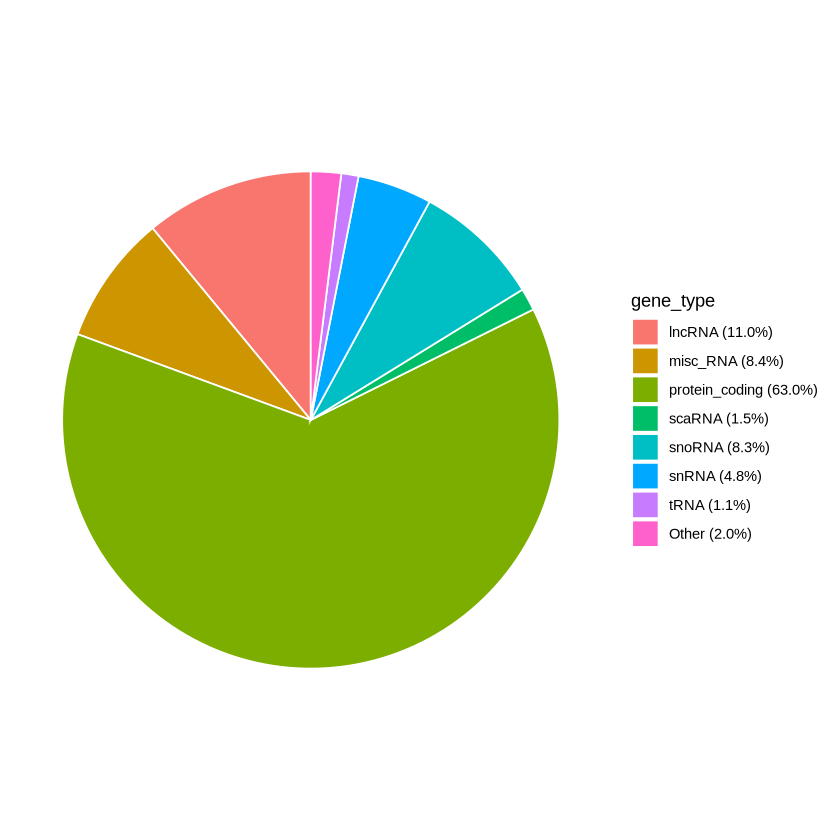

In [197]:
library(dplyr)
library(forcats)
library(ggplot2)

df <- genome_m$merged_data %>%
  filter(!is.na(gene_type)) %>%
  mutate(gene_type2 = as.character(gene_type))

min_prop <- 0.01

df <- df %>%
  mutate(
    gene_type_lumped = fct_lump_prop(
      factor(gene_type2),
      prop = min_prop,
      other_level = "Other"
    )
  )

plot_df <- df %>%
  count(gene_type_lumped, name = "n") %>%
  mutate(prop = n / sum(n),
         label = paste0(as.character(gene_type_lumped),
                        " (", sprintf("%.1f%%", 100 * prop), ")"))

lab_map <- setNames(plot_df$label, plot_df$gene_type_lumped)

ggplot(plot_df, aes(x = "", y = n, fill = gene_type_lumped)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  theme_void() +
  labs(fill = "gene_type") +
  scale_fill_discrete(labels = lab_map)


                  3'UTR                   5'UTR                     CDS 
                    521                     239                     373 
                   exon              intergenic                  intron 
                   1307                    1319                    2466 
small RNA transcription 
                    541 

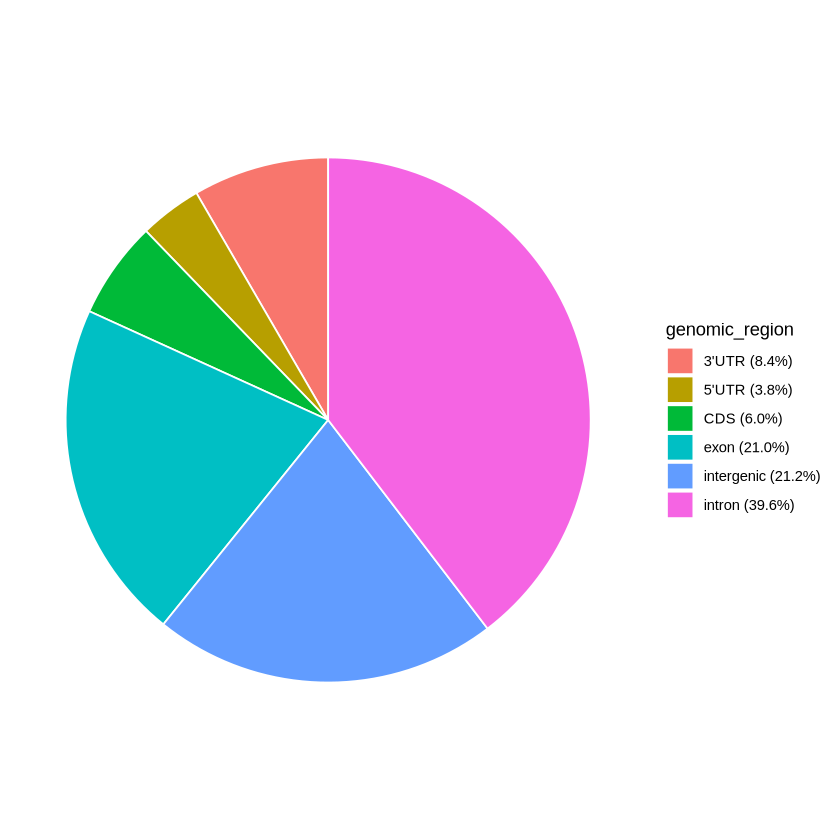

In [198]:
tab <- table(genome_m$merged_data$genomic_region, useNA = "ifany")
tab
df <- genome_m$merged_data %>%
  filter(!is.na(genomic_region),
         genomic_region != "small RNA transcription")

plot_df <- df %>%
  count(genomic_region, name = "n") %>%
  mutate(prop = n / sum(n))

# 给图例加上百分比
lab_map <- setNames(
  paste0(plot_df$genomic_region, " (", sprintf("%.1f%%", 100 * plot_df$prop), ")"),
  plot_df$genomic_region
)

ggplot(plot_df, aes(x = "", y = n, fill = genomic_region)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  theme_void() +
  labs(fill = "genomic_region") +
  scale_fill_discrete(labels = lab_map)

In [114]:
#filter_samples(m, max_missing_rate = 0.8)

Checking sample missing-rate (threshold: 0.80) ...

  [drop] PU27  missing-rate = 98.6%

  Removed 1 sample(s); 37 sample(s) remain.



In [199]:
#save_merged(m, "/home/tangyh/script/Modsite/modsite.Rcheck/merged_annotated.tsv")
save(genome_m, file = "/home/tangyh/script/Modsite/modsite.Rcheck/genome_m.RData")
#load("/home/tangyh/script/Modsite/modsite.Rcheck/genome_m.RData")

In [4]:
load("/home/tangyh/script/Modsite/modsite.Rcheck/genome_m.RData")

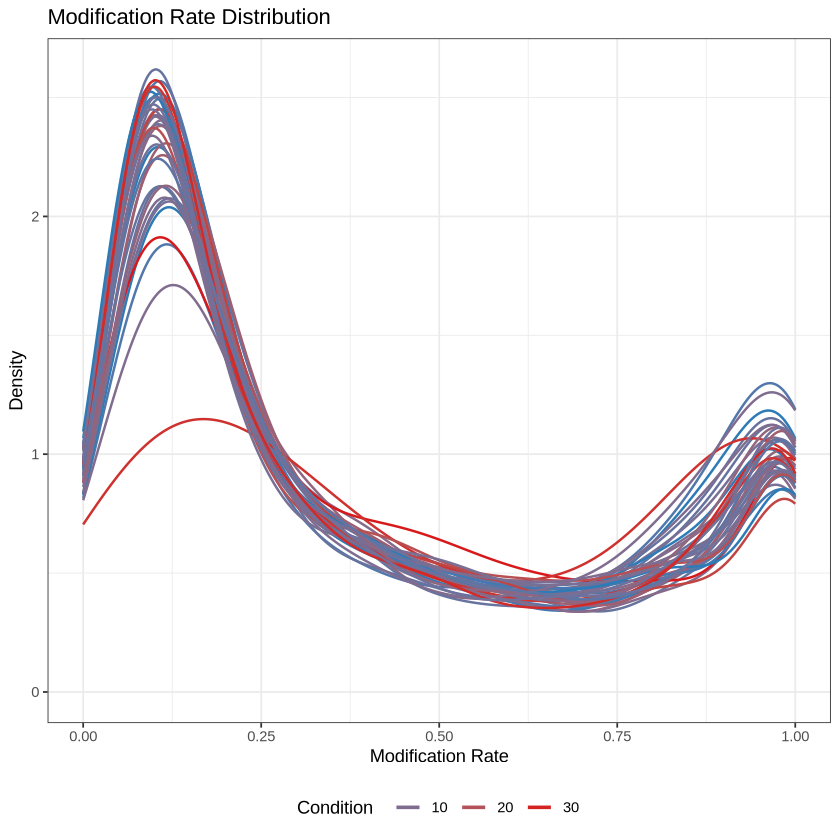

In [201]:
plot_mod_rate_distribution(genome_m, condition = NULL)

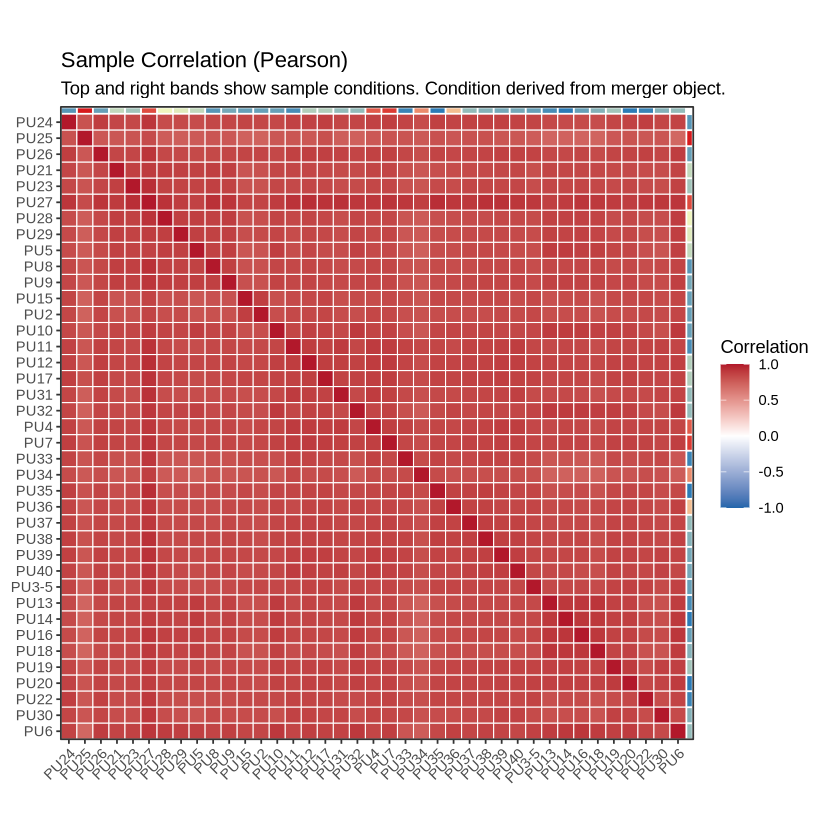

In [202]:
plot_sample_correlation(genome_m)

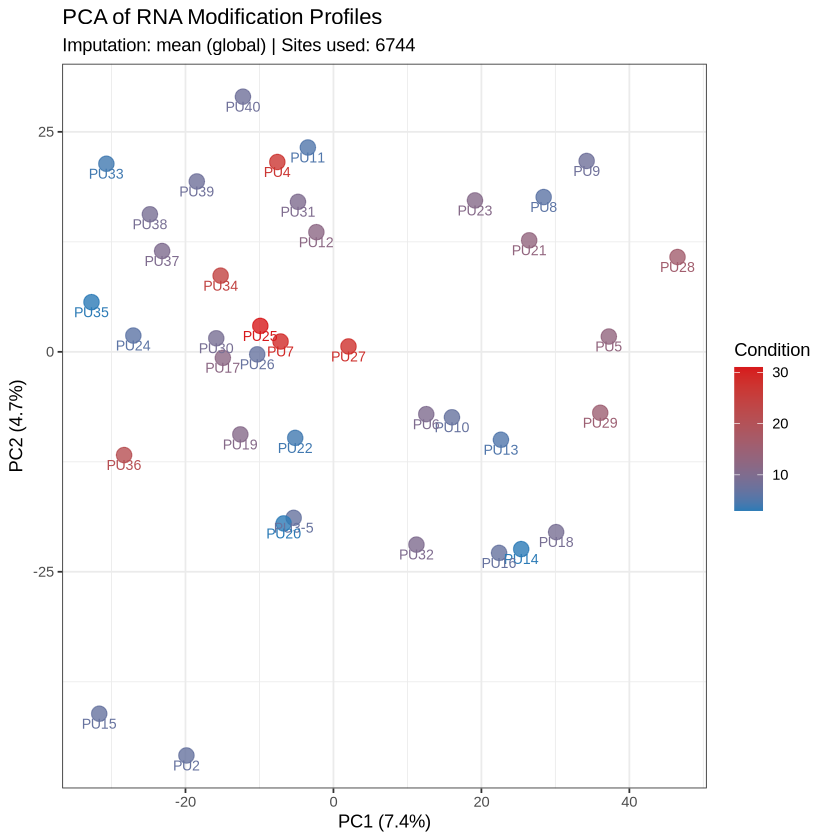

In [203]:
plot_merger_pca(genome_m,impute_scope = "global")

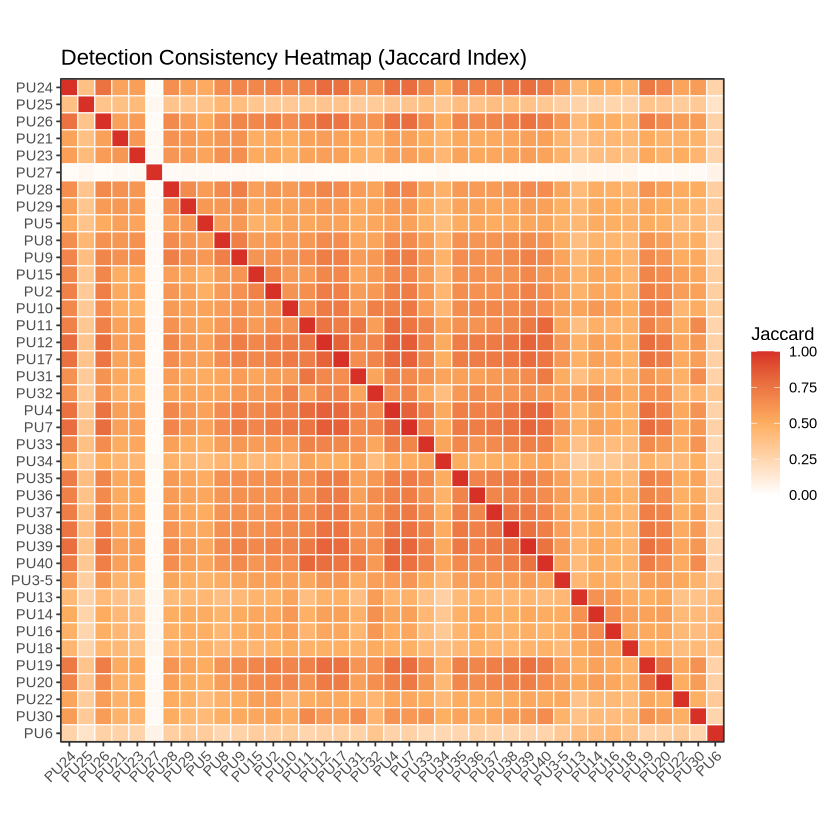

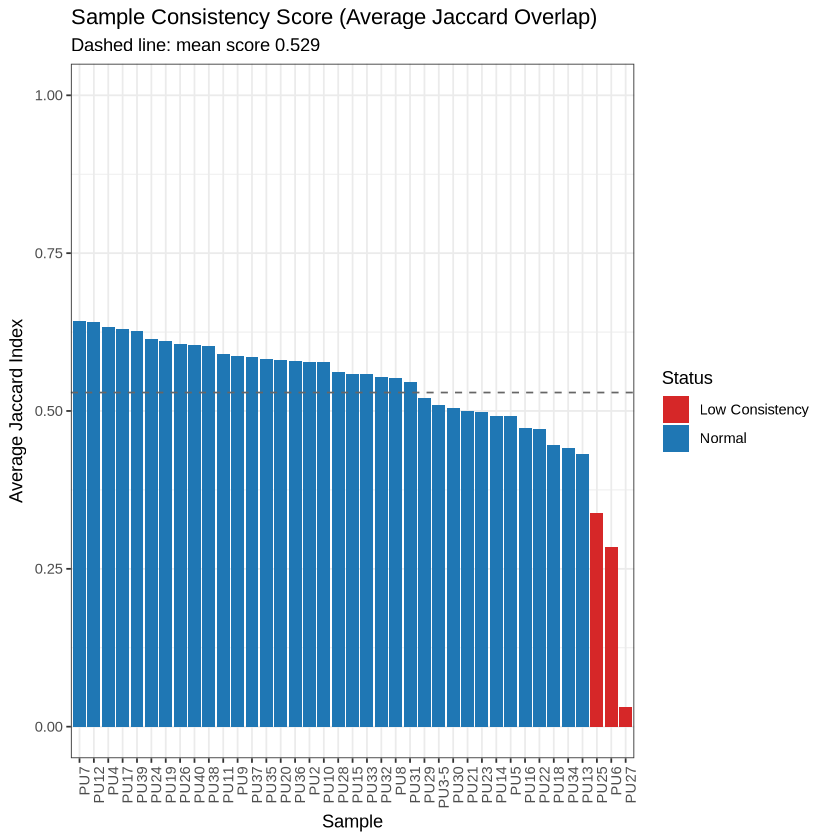

In [206]:
consistency <- plot_detection_consistency(genome_m, show_score_bar = TRUE)

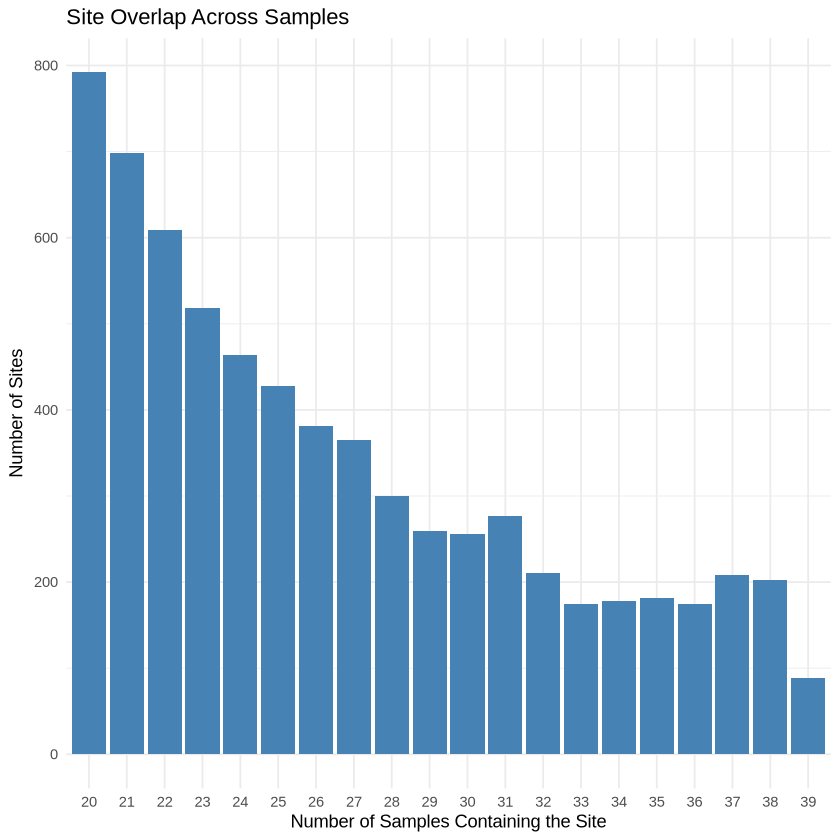

In [208]:
plot_site_overlap(genome_m)

In [8]:
genome_m$sample_meta <- meta2

In [21]:
filter_samples(genome_m, max_missing_rate = 0.8)

Checking sample missing-rate (threshold: 0.80) ...

  No samples removed.



In [10]:
genome_m$sample_meta$Gender <- as.factor(genome_m$sample_meta$Gender)
genome_m$sample_meta

sample_id,ECOG_PS,CEA,CA125,CA724,CA199,Grade,PFS,OS,Gender,Age,PFS_status,OS_status,ID
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<int>,<int>,<int>,<fct>
PU24,1,0,0,1,1,2,5,6,2,65,1,1,PU24
PU25,0,1,0,0,0,2,31,31,1,72,0,0,PU25
PU26,0,0,1,1,1,2,5,7,1,52,1,1,PU26
PU21,1,1,1,0,1,2,3,13,1,72,1,1,PU21
PU23,0,1,1,1,0,1,11,11,2,53,1,1,PU23
PU28,0,0,1,1,0,2,11,16,1,76,1,1,PU28
PU29,0,1,1,1,1,1,15,15,1,71,0,0,PU29
PU5,1,0,0,0,1,1,8,13,1,67,1,1,PU5
PU8,0,0,1,0,0,1,2,6,2,45,1,1,PU8


In [8]:
save(genome_m, file = "/home/tangyh/script/Modsite/modsite.Rcheck/genome_m2.RData")

In [ ]:
#######Cox for OS

In [34]:
genome_m$merged_data

,chrom,pos,ref,strand,motif,PU24,depth_PU24,PU25,depth_PU25,PU26,⋯,PU19,depth_PU19,PU20,depth_PU20,PU22,depth_PU22,PU30,depth_PU30,PU6,depth_PU6
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
1,1,135007,A,-,TTTCC,0.06050955,314,NA,0,0.05681818,⋯,0.05660377,53,0.06756757,74,0.17857143,28,NA,0,NA,0
2,1,629617,T,+,TGTTG,0.16666667,6,NA,0,NA,⋯,0.27868852,62,0.15789474,19,NA,0,0.18750000,16,NA,0
3,1,629622,T,+,GTTAT,0.28571429,7,NA,0,NA,⋯,0.21212121,66,0.20000000,20,NA,0,0.09523810,21,NA,0
4,1,630727,T,+,AGTAA,0.05882353,17,NA,0,0.10000000,⋯,0.09701493,138,0.06818182,44,NA,0,0.06896552,30,NA,0
5,1,632693,T,+,GATAT,0.00000000,156,1.0000000,239,0.00000000,⋯,0.33333333,466,1.00000000,364,0.00000000,28,0.33333333,772,0.0000000,12
6,1,632695,T,+,TATTA,0.00000000,153,0.0000000,234,0.00000000,⋯,1.00000000,462,0.50000000,360,0.00000000,28,0.66666667,781,0.0000000,11
7,1,632696,T,+,ATTAG,0.00000000,151,0.0000000,224,0.00000000,⋯,1.00000000,444,0.00000000,360,0.00000000,27,1.00000000,777,0.0000000,12
8,1,632881,T,+,CCTTT,0.07462687,67,NA,0,0.09090909,⋯,0.07407407,54,0.14705882,34,0.05882353,17,NA,0,NA,0
9,1,633372,T,+,TTTAT,0.27272727,11,NA,0,0.80000000,⋯,0.42857143,21,0.54545455,22,NA,0,0.48148148,27,NA,0


In [33]:
 length(genome_m$condition)

[1] 38

In [35]:
pure_df_cont <- make_pure_rate_table(
  merged_df = genome_m$merged_data,
  condition = genome_m$condition,  # 连续变量
  impute_method = "mean",
  impute_scope = "auto"           # 会自动走 global
)

In [36]:
pure_df_cont

,site_id,chrom,pos,ref,PU24,PU25,PU26,PU21,PU23,PU28,⋯,PU3-5,PU13,PU14,PU16,PU18,PU19,PU20,PU22,PU30,PU6
,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1_135007_A_-,1,135007,A,0.06050955,0.08419213,0.05681818,0.08419213,0.08419213,0.08419213,⋯,0.1111111,0.08419213,0.08419213,0.06250000,0.08419213,0.05660377,0.06756757,0.17857143,0.08419213,0.08419213
2,1_629617_T_+,1,629617,T,0.16666667,0.25816934,0.25816934,0.25816934,0.25816934,0.25816934,⋯,0.2581693,0.12500000,0.37500000,0.25000000,0.30000000,0.27868852,0.15789474,0.25816934,0.18750000,0.25816934
3,1_629622_T_+,1,629622,T,0.28571429,0.21838129,0.21838129,0.21838129,0.21838129,0.21838129,⋯,0.2183813,0.25000000,0.37500000,0.37500000,0.30000000,0.21212121,0.20000000,0.21838129,0.09523810,0.21838129
4,1_630727_T_+,1,630727,T,0.05882353,0.11402832,0.10000000,0.14285714,0.25000000,0.22222222,⋯,0.1111111,0.11402832,0.11402832,0.06451613,0.16666667,0.09701493,0.06818182,0.11402832,0.06896552,0.11402832
5,1_632693_T_+,1,632693,T,0.00000000,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,⋯,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.33333333,1.00000000,0.00000000,0.33333333,0.00000000
6,1_632695_T_+,1,632695,T,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,⋯,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.50000000,0.00000000,0.66666667,0.00000000
7,1_632696_T_+,1,632696,T,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,⋯,0.0000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000
8,1_632881_T_+,1,632881,T,0.07462687,0.11208200,0.09090909,0.11208200,0.11208200,0.11208200,⋯,0.1000000,0.14285714,0.11208200,0.22222222,0.11208200,0.07407407,0.14705882,0.05882353,0.11208200,0.11208200
9,1_633372_T_+,1,633372,T,0.27272727,0.50521711,0.80000000,0.50521711,0.50521711,0.50521711,⋯,0.8000000,0.50521711,0.66666667,0.50521711,0.50521711,0.42857143,0.54545455,0.50521711,0.48148148,0.50521711


In [44]:
# 提取甲基化矩阵（site × sample），转置为 sample × site
meth_mat <- pure_df_cont[, 5:ncol(pure_df_cont)]  # 去掉前4列注释列
# 验证顺序是否一致
all(colnames(meth_mat) == meta$sample_id)  # 必须返回 TRUE
common_samples <- intersect(colnames(meth_mat), meta$sample_id)
cat("共同样本数：", length(common_samples), "\n")

# 同时过滤两个数据框，并保证顺序一致
meth_mat_use <- meth_mat[, common_samples]
meta_use     <- meta[meta$sample_id %in% common_samples, ]
meta_use     <- meta_use[match(common_samples, meta_use$sample_id), ]

# 验证
all(colnames(meth_mat_use) == meta_use$sample_id)  # 必须 TRUE

Warning message in `==.default`(colnames(meth_mat), meta$sample_id):
“longer object length is not a multiple of shorter object length”
Warning message in is.na(e1) | is.na(e2):
“longer object length is not a multiple of shorter object length”


[1] FALSE

共同样本数： 38 


[1] TRUE

In [52]:
meth_mat_use

,PU24,depth_PU24,PU25,depth_PU25,PU26,depth_PU26,PU21,depth_PU21,PU23,depth_PU23,⋯,PU19,depth_PU19,PU20,depth_PU20,PU22,depth_PU22,PU30,depth_PU30,PU6,depth_PU6
,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
1,0.06050955,314,NA,0,0.05681818,88,NA,0,NA,0,⋯,0.05660377,53,0.06756757,74,0.17857143,28,NA,0,NA,0
2,0.16666667,6,NA,0,NA,0,NA,0,NA,0,⋯,0.27868852,62,0.15789474,19,NA,0,0.18750000,16,NA,0
3,0.28571429,7,NA,0,NA,0,NA,0,NA,0,⋯,0.21212121,66,0.20000000,20,NA,0,0.09523810,21,NA,0
4,0.05882353,17,NA,0,0.10000000,20,0.14285714,7,0.2500000,8,⋯,0.09701493,138,0.06818182,44,NA,0,0.06896552,30,NA,0
5,0.00000000,156,1.0000000,239,0.00000000,152,0.00000000,503,0.0000000,148,⋯,0.33333333,466,1.00000000,364,0.00000000,28,0.33333333,772,0.0000000,12
6,0.00000000,153,0.0000000,234,0.00000000,151,0.00000000,498,0.0000000,154,⋯,1.00000000,462,0.50000000,360,0.00000000,28,0.66666667,781,0.0000000,11
7,0.00000000,151,0.0000000,224,0.00000000,154,0.00000000,503,0.0000000,149,⋯,1.00000000,444,0.00000000,360,0.00000000,27,1.00000000,777,0.0000000,12
8,0.07462687,67,NA,0,0.09090909,66,NA,0,NA,0,⋯,0.07407407,54,0.14705882,34,0.05882353,17,NA,0,NA,0
9,0.27272727,11,NA,0,0.80000000,5,NA,0,NA,0,⋯,0.42857143,21,0.54545455,22,NA,0,0.48148148,27,NA,0


In [45]:
meta_use

,sample_id,ECOG_PS,CEA,CA125,CA724,CA199,Grade,PFS,OS,Gender,Age,PFS_status,OS_status
,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<int>,<fct>,<fct>
4,PU24,1,0,0,1,1,2,5,6,2,65,1,1
10,PU25,0,1,0,0,0,2,31,31,1,72,0,0
7,PU26,0,0,1,1,1,2,5,7,1,52,1,1
8,PU21,1,1,1,0,1,2,3,13,1,72,1,1
3,PU23,0,1,1,1,0,1,11,11,2,53,1,1
32,PU28,0,0,1,1,0,2,11,16,1,76,1,1
26,PU29,0,1,1,1,1,1,15,15,1,71,0,0
33,PU5,1,0,0,0,1,1,8,13,1,67,1,1
18,PU8,0,0,1,0,0,1,2,6,2,45,1,1


In [56]:
meth_mat_use

,PU24,depth_PU24,PU25,depth_PU25,PU26,depth_PU26,PU21,depth_PU21,PU23,depth_PU23,⋯,PU19,depth_PU19,PU20,depth_PU20,PU22,depth_PU22,PU30,depth_PU30,PU6,depth_PU6
,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
1,0.06050955,314,NA,0,0.05681818,88,NA,0,NA,0,⋯,0.05660377,53,0.06756757,74,0.17857143,28,NA,0,NA,0
2,0.16666667,6,NA,0,NA,0,NA,0,NA,0,⋯,0.27868852,62,0.15789474,19,NA,0,0.18750000,16,NA,0
3,0.28571429,7,NA,0,NA,0,NA,0,NA,0,⋯,0.21212121,66,0.20000000,20,NA,0,0.09523810,21,NA,0
4,0.05882353,17,NA,0,0.10000000,20,0.14285714,7,0.2500000,8,⋯,0.09701493,138,0.06818182,44,NA,0,0.06896552,30,NA,0
5,0.00000000,156,1.0000000,239,0.00000000,152,0.00000000,503,0.0000000,148,⋯,0.33333333,466,1.00000000,364,0.00000000,28,0.33333333,772,0.0000000,12
6,0.00000000,153,0.0000000,234,0.00000000,151,0.00000000,498,0.0000000,154,⋯,1.00000000,462,0.50000000,360,0.00000000,28,0.66666667,781,0.0000000,11
7,0.00000000,151,0.0000000,224,0.00000000,154,0.00000000,503,0.0000000,149,⋯,1.00000000,444,0.00000000,360,0.00000000,27,1.00000000,777,0.0000000,12
8,0.07462687,67,NA,0,0.09090909,66,NA,0,NA,0,⋯,0.07407407,54,0.14705882,34,0.05882353,17,NA,0,NA,0
9,0.27272727,11,NA,0,0.80000000,5,NA,0,NA,0,⋯,0.42857143,21,0.54545455,22,NA,0,0.48148148,27,NA,0


In [53]:
meth_mat_use = genome_m$merged_data[, 6:ncol(genome_m$merged_data)]

In [54]:
library(survival)
library(foreach)
library(doParallel)

# 开启并行
cl <- makeCluster(4)
registerDoParallel(cl)
meta_use$OS_status <- as.numeric(as.character(meta_use$OS_status))
meta_use$Gender    <- as.numeric(as.character(meta_use$Gender))
meta_use$OS        <- as.numeric(meta_use$OS)
meta_use$Age       <- as.numeric(meta_use$Age)
ewas_OS <- foreach(i = 1:nrow(meth_mat_use), 
                   .combine = rbind, 
                   .packages = "survival") %dopar% {
  
  site <- rownames(meth_mat_use)[i]
  
  df <- data.frame(
    OS        = meta_use$OS,
    OS_status = meta_use$OS_status,
    meth      = as.numeric(meth_mat_use[i, ]),
    Age       = meta_use$Age,
    Gender    = meta_use$Gender
  )
  
  fit <- tryCatch(
    coxph(Surv(OS, OS_status) ~ meth + Age + Gender, data = df),
    error   = function(e) NULL,
    warning = function(w) NULL
  )
  
  if (is.null(fit)) {
    return(data.frame(
      site_id = site, HR = NA, CI_low = NA, 
      CI_high = NA, z = NA, pval = NA
    ))
  }
  
  s <- summary(fit)$coefficients["meth", ]
  
  data.frame(
    site_id = site,
    HR      = exp(s["coef"]),
    CI_low  = exp(s["coef"] - 1.96 * s["se(coef)"]),
    CI_high = exp(s["coef"] + 1.96 * s["se(coef)"]),
    z       = s["z"],
    pval    = s["Pr(>|z|)"]
  )
}

stopCluster(cl)

# FDR 校正
ewas_OS$FDR <- p.adjust(ewas_OS$pval, method = "BH")

# 按 p 值排序
ewas_OS <- ewas_OS[order(ewas_OS$pval), ]

# 查看结果
cat("总位点数：", nrow(ewas_OS), "\n")
cat("FDR < 0.05 位点数：", sum(ewas_OS$FDR < 0.05, na.rm = TRUE), "\n")
cat("nominal p < 0.05 位点数：", sum(ewas_OS$pval < 0.05, na.rm = TRUE), "\n")

head(ewas_OS, 20)

总位点数： 6766 
FDR < 0.05 位点数： 0 
nominal p < 0.05 位点数： 263 


,site_id,HR,CI_low,CI_high,z,pval,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coef6240,3534.1,1.0017625,1.0007408,1.0027853,3.382245,0.0007189588,0.7575442
coef4473,4474,0.9083710,0.8549429,0.9651379,-3.107331,0.0018878517,0.7575442
coef5990,5991,1.0048687,1.0015857,1.0081624,2.908958,0.0036263591,0.7575442
coef5971,5972,1.0062764,1.0020090,1.0105620,2.885591,0.0039067935,0.7575442
coef5833,5834,0.9524911,0.9214442,0.9845840,-2.878893,0.0039907332,0.7575442
coef5834,5835,0.9516178,0.9188351,0.9855701,-2.772641,0.0055603389,0.7575442
coef5987,5988,1.0081289,1.0023345,1.0139567,2.752883,0.0059072968,0.7575442
coef3531,3532,0.9304923,0.8838950,0.9795462,-2.748412,0.0059884749,0.7575442
coef1375,1376,0.9689870,0.9473454,0.9911231,-2.733725,0.0062622307,0.7575442


In [55]:
# 一次性计算所有校正方法，方便比较
ewas_OS$FDR_BH  <- p.adjust(ewas_OS$pval, method = "BH")   # 最推荐
ewas_OS$FDR_BY  <- p.adjust(ewas_OS$pval, method = "BY")   
ewas_OS$p_bonf  <- p.adjust(ewas_OS$pval, method = "bonferroni")

# Bonferroni 阈值
bonf_threshold <- 0.05 / nrow(ewas_OS)
cat("Bonferroni 阈值：", bonf_threshold, "\n")  # 约 7.4e-6

# 各方法显著位点数
cat("Bonferroni 显著位点：", sum(ewas_OS$p_bonf  < 0.05, na.rm = TRUE), "\n")
cat("BH FDR 显著位点：",     sum(ewas_OS$FDR_BH  < 0.05, na.rm = TRUE), "\n")
cat("BY FDR 显著位点：",     sum(ewas_OS$FDR_BY  < 0.05, na.rm = TRUE), "\n")
cat("Nominal p<0.05 位点：", sum(ewas_OS$pval    < 0.05, na.rm = TRUE), "\n")

Bonferroni 阈值： 7.389891e-06 
Bonferroni 显著位点： 0 
BH FDR 显著位点： 0 
BY FDR 显著位点： 0 
Nominal p<0.05 位点： 263 


In [48]:
ewas_OS

,site_id,HR,CI_low,CI_high,z,pval,FDR,FDR_BH,FDR_BY,p_bonf
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
coef1749,1750,2.633295e-03,1.041140e-04,6.660238e-02,-3.603604,0.0003138354,0.6099970,0.6099970,1,1
coef1552,1553,7.352783e-04,1.367448e-05,3.953601e-02,-3.549037,0.0003866424,0.6099970,0.6099970,1,1
coef5411,5412,2.530995e+08,5.183970e+03,1.235720e+13,3.512850,0.0004433273,0.6099970,0.6099970,1,1
coef1672,1673,4.982452e+07,2.276266e+03,1.090594e+12,3.476088,0.0005087845,0.6099970,0.6099970,1,1
coef4233,4234,5.586434e-05,2.034455e-07,1.533986e-02,-3.418076,0.0006306552,0.6099970,0.6099970,1,1
coef429,430,3.025146e-05,7.644564e-08,1.197126e-02,-3.410241,0.0006490560,0.6099970,0.6099970,1,1
coef3495,3496,9.037200e+04,1.237643e+02,6.598913e+07,3.392364,0.0006929226,0.6099970,0.6099970,1,1
coef2984,2985,9.767779e-09,2.215542e-13,4.306372e-04,-3.380476,0.0007236026,0.6099970,0.6099970,1,1
coef4430,4431,3.106031e+05,1.778525e+02,5.424400e+08,3.320246,0.0008993803,0.6739356,0.6739356,1,1


In [44]:
library(ggplot2)
library(ggrepel)

# 准备绘图数据
plot_df <- ewas_OS[!is.na(ewas_OS$pval), ]  # 去除NA

# 添加 log2HR 和 -log10p
plot_df$log2HR   <- log2(plot_df$HR)
plot_df$neg_logP <- -log10(plot_df$pval)

# 定义显著性阈值
p_threshold  <- 0.05                          # nominal p
hr_threshold <- log2(1.5)                     # |log2HR| > log2(1.5)，即HR>1.5或<0.67

# 添加分组标签
plot_df$group <- "Not significant"
plot_df$group[plot_df$pval < p_threshold & plot_df$log2HR >  hr_threshold] <- "High risk"
plot_df$group[plot_df$pval < p_threshold & plot_df$log2HR < -hr_threshold] <- "Low risk"

# 统计各组数量
table(plot_df$group)

# 提取需要标注的位点（最显著的前10个）
label_df <- head(plot_df[plot_df$group != "Not significant", ], 10)
# 如果显著位点不够10个，就取p值最小的前10个
if (nrow(label_df) < 5) {
  label_df <- head(plot_df, 10)
}

# 绘图
ggplot(plot_df, aes(x = log2HR, y = neg_logP, color = group)) +
  
  # 散点
  geom_point(alpha = 0.6, size = 1.5) +
  
  # 颜色
  scale_color_manual(
    values = c(
      "Not significant" = "grey70",
      "High risk"       = "#E64B35",   # 红色：高风险
      "Low risk"        = "#4DBBD5"    # 蓝色：低风险
    )
  ) +
  
  # 阈值线
  geom_hline(yintercept = -log10(p_threshold), 
             linetype = "dashed", color = "black", linewidth = 0.5) +
  geom_vline(xintercept =  hr_threshold, 
             linetype = "dashed", color = "black", linewidth = 0.5) +
  geom_vline(xintercept = -hr_threshold, 
             linetype = "dashed", color = "black", linewidth = 0.5) +
  
  # 标注显著位点名称
  geom_text_repel(
    data          = label_df,
    aes(label     = site_id),
    size          = 3,
    max.overlaps  = 20,
    box.padding   = 0.5,
    color         = "black"
  ) +
  
  # 坐标轴标签
  labs(
    x     = expression(log[2]("HazardRatio")),
    y     = expression(-log[10]("Pvalue")),
    title = "EWAS Volcano Plot — Overall Survival",
    color = ""
  ) +
  
  # 主题
  theme_bw(base_size = 14) +
  theme(
    legend.position   = c(0.85, 0.85),
    legend.background = element_rect(fill = "white", color = "grey80"),
    plot.title        = element_text(hjust = 0.5, face = "bold"),
    panel.grid.minor  = element_blank()
  )

Warning message in lapply(list(...), as.character):
“restarting interrupted promise evaluation”
Warning message in lapply(list(...), as.character):
“internal error 1 in R_decompress1 with libdeflate”


ERROR: Error: package or namespace load failed for ‘ggplot2’:
 .onLoad failed in loadNamespace() for 'ggplot2', details:
  call: lapply(list(...), as.character)
  error: lazy-load database '/home/tangyh/anaconda3/envs/rnamod_r/lib/R/library/S7/R/S7.rdb' is corrupt


In [13]:
out_dss <- run_dss(
  merger = genome_m,
  fixed = c("OS", "Gender", "Age"),
  primary_term = "OS",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  min_primary_per_level = 2L,
  min_primary_sd = 1e-3,
  on_error = "warn",
  smoothing = FALSE,
  verbose = TRUE
)

Warning message:
“[run_glmm_bayes] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
Warning message:
“[run_glmm_bayes] Fixed variable "Age" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
[run_glmm_bayes] Removed 77611 observation(s) with NA k (missing rate or depth).

[run_dss] Running internal DSS multifactor fitting (smoothing = FALSE) ...

[run_dss] Fitting site-wise multifactor model ...



In [14]:
out_dss$primary_term_backfill

,site_id,chrom,pos,ref,strand,motif,OS_est_logodds,OS_or,OS_p.value,OS_adj_p.value,fit_ok,error_msg,primary_match_error,posterior_tail_prob,or_extreme
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>
6767,1_135007_A_-,1,135007,A,-,TTTCC,NA,NA,0.67369203,0.9938061,TRUE,NA,NA,NA,FALSE
6768,1_629617_T_+,1,629617,T,+,TGTTG,NA,NA,0.61955245,0.9938061,TRUE,NA,NA,NA,FALSE
6769,1_629622_T_+,1,629622,T,+,GTTAT,NA,NA,0.64345500,0.9938061,TRUE,NA,NA,NA,FALSE
6770,1_630727_T_+,1,630727,T,+,AGTAA,NA,NA,0.96298211,0.9969521,TRUE,NA,NA,NA,FALSE
6771,1_632693_T_+,1,632693,T,+,GATAT,NA,NA,0.07013153,0.7831968,TRUE,NA,NA,NA,FALSE
6772,1_632695_T_+,1,632695,T,+,TATTA,NA,NA,0.72965818,0.9938061,TRUE,NA,NA,NA,FALSE
6773,1_632696_T_+,1,632696,T,+,ATTAG,NA,NA,0.94897835,0.9969521,TRUE,NA,NA,NA,FALSE
6774,1_632881_T_+,1,632881,T,+,CCTTT,NA,NA,0.53661062,0.9907373,TRUE,NA,NA,NA,FALSE
6775,1_633372_T_+,1,633372,T,+,TTTAT,NA,NA,0.58931049,0.9908735,TRUE,NA,NA,NA,FALSE


In [9]:
out <- run_glmm_bayes(
  merger = genome_m,
  fixed = c("OS"),   # 样本层固定效应
  random = NULL,               # 不用随机效应就设 NULL
  primary_term = "OS",      # 主要关注的变量（必须在 fixed 里）
  min_depth_site = 5,
  min_samples_per_site = 5,
  adj_method = "BH",
  on_error = "warn",
  phi_vars = NULL,             # 现在会被忽略（保留 NULL 最清晰）
  max_iter = 10,
  tol = 1e-4,
  verbose = TRUE
)

Warning message:
“[run_glmm_bayes] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
[run_glmm_bayes] Removed 77611 observation(s) with NA k (missing rate or depth).

[run_glmm_bayes] Starting hierarchical MAP fitting for 6766 site(s).

[run_glmm_bayes] Iteration 1/10: fitted=6766, max_change=12.44

[run_glmm_bayes] Iteration 2/10: fitted=6698, max_change=2.451e+16

[run_glmm_bayes] Iteration 3/10: fitted=6766, max_change=2.463e+14

[run_glmm_bayes] Iteration 4/10: fitted=6765, max_change=3.587e+12

[run_glmm_bayes] Iteration 5/10: fitted=6766, max_change=3.587e+12

[run_glmm_bayes] Iteration 6/10: fitted=6766, max_change=0.6043

[run_glmm_bayes] Iteration 7/10: fitted=6766, max_change=0.06429

[run_glmm_bayes] Iteration 8/10: fitted=6766, max_change=0.3609

[run_glmm_bayes] Iteration 9/10: fitted=6766, max_change=0.1078

[run_glmm_bayes] Iteration 10/10: fitted=6766, max_change=0.05805

Warning message:
“[run_glmm_baye

In [15]:
out_dss$primary_term_backfill$OS_adj_p.value[out_dss$primary_term_backfill$OS_adj_p.value<0.05]

[1] 3.975145e-02 3.975145e-02 2.618757e-02 2.618757e-02 6.015842e-07
 [6] 2.618757e-02 8.273679e-03 2.482801e-02 2.482801e-02 5.453846e-04
[11] 3.553676e-02 4.242060e-02 2.482801e-02 3.975145e-02 4.133949e-02

In [260]:
glmm_out_bayes <- run_glmm_bayes(
  merger = genome_m,
  fixed = c("OS"),
  primary_term = "OS",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  min_primary_per_level = 2L,
  beta_extreme_threshold = Inf,
  winsorize_q = c(0.01, 0.99),
  max_coef_sd = 5,
  max_random_sd = 5,
  max_phi_sd = 5,
  n_cores = 1L,
  on_error = "warn",
  max_iter = 18L,
  tol = 1e-4,
  verbose = TRUE
)

Warning message:
“[run_glmm_bayes] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
[run_glmm_bayes] Removed 77611 observation(s) with NA k (missing rate or depth).

[run_glmm_bayes] Starting hierarchical MAP fitting for 6766 site(s) after contrast filtering (dropped=0).

[run_glmm_bayes] Iteration 1/18: fitted=6766, usable=6766, extreme=0, winsorized_cells=272, max_change=2.708

[run_glmm_bayes] Iteration 2/18: fitted=6762, usable=6762, extreme=0, winsorized_cells=272, max_change=23.14

[run_glmm_bayes] Iteration 3/18: fitted=6756, usable=6756, extreme=0, winsorized_cells=272, max_change=119

[run_glmm_bayes] Iteration 4/18: fitted=6759, usable=6759, extreme=0, winsorized_cells=272, max_change=120.4

[run_glmm_bayes] Iteration 5/18: fitted=6765, usable=6765, extreme=0, winsorized_cells=272, max_change=31.1

[run_glmm_bayes] Iteration 6/18: fitted=6766, usable=6766, extreme=0, winsorized_cells=272, max_change=10.11

[r

In [263]:
pri <- subset(glmm_out_bayes$results_long, is_primary %in% TRUE)
c(
  n_site = nrow(pri),
  est_non_na = sum(!is.na(pri$estimate)),
  se_non_na = sum(!is.na(pri$std.error)),
  p_non_na = sum(!is.na(pri$p.value))
)
table(is.na(pri$std.error), is.na(pri$p.value))

n_site est_non_na  se_non_na   p_non_na 
      6766       6766       1594       1594

       
        FALSE TRUE
  FALSE  1594    0
  TRUE      0 5172

In [264]:
legacy_env <- new.env(parent = globalenv())
sys.source("R/diff_glmm_bayes_0.R", envir = legacy_env)
glmm_out_bayes <- legacy_env$run_glmm_bayes(
  merger = genome_m,
  fixed = c("OS"),
  primary_term = "OS",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  n_cores = 1L,
  on_error = "warn",
  max_iter = 18L,
  tol = 1e-4,
  verbose = TRUE
)

Warning message:
“[run_glmm_bayes] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
[run_glmm_bayes] Removed 77611 observation(s) with NA k (missing rate or depth).

[run_glmm_bayes] Starting hierarchical MAP fitting for 6766 site(s).

[run_glmm_bayes] Iteration 1/18: fitted=6766, max_change=12.44

[run_glmm_bayes] Iteration 2/18: fitted=6698, max_change=2.451e+16

[run_glmm_bayes] Iteration 3/18: fitted=6766, max_change=2.463e+14

[run_glmm_bayes] Iteration 4/18: fitted=6765, max_change=3.587e+12

[run_glmm_bayes] Iteration 5/18: fitted=6766, max_change=3.587e+12

[run_glmm_bayes] Iteration 6/18: fitted=6766, max_change=0.6043

[run_glmm_bayes] Iteration 7/18: fitted=6766, max_change=0.06429

[run_glmm_bayes] Iteration 8/18: fitted=6766, max_change=0.3609

[run_glmm_bayes] Iteration 9/18: fitted=6766, max_change=0.1078

[run_glmm_bayes] Iteration 10/18: fitted=6766, max_change=0.05805

[run_glmm_bayes] Iteration 11/18

In [265]:
glmm_out_bayes$primary_term_backfill

,site_id,chrom,pos,ref,strand,motif,OS_est_logodds,OS_or,OS_p.value,OS_adj_p.value,fit_ok,error_msg,primary_match_error,posterior_tail_prob,or_extreme
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>
2,1_135007_A_-,1,135007,A,-,TTTCC,-4.839227e-03,9.951725e-01,0.73084274,0.9424306,TRUE,NA,NA,0.73084274,FALSE
4,1_629617_T_+,1,629617,T,+,TGTTG,2.024659e+01,6.208464e+08,NA,NA,TRUE,NA,NA,NA,TRUE
6,1_629622_T_+,1,629622,T,+,GTTAT,1.252345e+03,Inf,NA,NA,TRUE,NA,NA,NA,TRUE
8,1_630727_T_+,1,630727,T,+,AGTAA,-1.360037e-03,9.986409e-01,0.92789620,0.9878760,TRUE,NA,NA,0.92789620,FALSE
10,1_632693_T_+,1,632693,T,+,GATAT,9.901470e-02,1.104083e+00,0.05407743,0.2994953,TRUE,NA,NA,0.05407743,FALSE
12,1_632695_T_+,1,632695,T,+,TATTA,-3.774234e-03,9.962329e-01,0.94579025,0.9904432,TRUE,NA,NA,0.94579025,FALSE
14,1_632696_T_+,1,632696,T,+,ATTAG,-3.779861e-02,9.629068e-01,0.55327940,0.8966244,TRUE,NA,NA,0.55327940,FALSE
16,1_632881_T_+,1,632881,T,+,CCTTT,3.879535e+02,3.062276e+168,NA,NA,TRUE,NA,NA,NA,TRUE
18,1_633372_T_+,1,633372,T,+,TTTAT,4.738857e+02,6.396648e+205,NA,NA,TRUE,NA,NA,NA,TRUE


In [27]:
glmm_out_basic <- run_glmm(
  merger = m,
  fixed = c("OS", "Gender", "Age"),
  primary_term = "OS",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  n_cores = 1L,
  on_error = "warn",
  phi = FALSE
)

[run_glmm] Removed 77689 observation(s) with NA k (missing rate or depth).

Warning message:
“[run_glmm] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
Warning message:
“[run_glmm] Fixed variable "Gender" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
Warning message:
“[run_glmm] Fixed variable "Age" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; false convergence (8). See vignette('troubles

In [ ]:
# 1. 看 fit 是否成功、Hessian 是否成功
table(glmm_out_bayes$primary_term_backfill$fit_ok,
      useNA = "ifany")
table(glmm_out_bayes$primary_term_backfill$error_msg,
      useNA = "ifany")
# 2. 看 SE 缺失模式：如果 estimate 都有但 SE 都缺，说明就是 Hessian 不可逆
df <- glmm_out_bayes$primary_term_backfill
sum(!is.na(df$OS_est_logodds))      # 估计成功的数量
sum(!is.na(df$OS_p.value))          # p 值非 NA 的数量
# 3. 看最终先验 SD 是否都贴着 floor
glmm_out_bayes$glmm_slot$coef_prior_sd
glmm_out_bayes$glmm_slot$phi_prior_sd
# 4. 看 EB 历史
sapply(glmm_out_bayes$glmm_slot$outer_history,
       function(x) c(n_ok = x$n_ok,
                     coef_sd = x$coef_prior_sd,
                     phi_sd = x$phi_prior_sd))

In [37]:
glmm_out_bayes <- run_glmm_bayes(
  merger = m,
  fixed = c("OS", "Gender", "Age"),
  primary_term = "OS",
  min_depth_site = 5L,
  min_samples_per_site = 6L,
  n_cores = 1L,
  on_error = "warn",
  max_iter = 8L,
  tol = 1e-4,
  verbose = TRUE
)

[run_glmm_bayes] Removed 77689 observation(s) with NA k (missing rate or depth).

[run_glmm_bayes] Starting hierarchical MAP fitting for 6513 site(s).

[run_glmm_bayes] Iteration 1/8: fitted=6513, max_change=5.166

[run_glmm_bayes] Iteration 2/8: fitted=6506, max_change=1.721e+05

[run_glmm_bayes] Iteration 3/8: fitted=6513, max_change=403.9

[run_glmm_bayes] Iteration 4/8: fitted=6513, max_change=9879

[run_glmm_bayes] Iteration 5/8: fitted=6513, max_change=10.69

[run_glmm_bayes] Iteration 6/8: fitted=6513, max_change=0.4995

[run_glmm_bayes] Iteration 7/8: fitted=6513, max_change=0.1938

[run_glmm_bayes] Iteration 8/8: fitted=6513, max_change=0.2546

Warning message:
“[run_glmm_bayes] Outer iteration reached max_iter=8 before convergence.”


In [38]:
glmm_out_bayes$primary_term_backfill

,site_id,chrom,pos,ref,strand,motif,OS_est_logodds,OS_or,OS_p.value,OS_adj_p.value,fit_ok,error_msg,primary_match_error,posterior_tail_prob,or_extreme
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>
2,1_135007_A_-,1,135007,A,-,TTTCC,2.331350e+01,1.333285e+10,NA,NA,TRUE,NA,NA,NA,TRUE
6,1_136772_A_-,1,136772,A,-,CCTCC,-2.630112e-02,9.740417e-01,1.334394e-01,6.511432e-01,TRUE,NA,NA,1.334394e-01,FALSE
10,1_629617_T_+,1,629617,T,+,TGTTG,1.060422e+01,4.030463e+04,NA,NA,TRUE,NA,NA,NA,TRUE
14,1_629622_T_+,1,629622,T,+,GTTAT,1.493148e+01,3.052535e+06,0.000000e+00,0.000000e+00,TRUE,NA,NA,0.000000e+00,TRUE
18,1_630727_T_+,1,630727,T,+,AGTAA,3.717206e+01,1.391937e+16,NA,NA,TRUE,NA,NA,NA,TRUE
22,1_632693_T_+,1,632693,T,+,GATAT,1.193839e-01,1.126802e+00,6.278196e-02,4.487524e-01,TRUE,NA,NA,6.278196e-02,FALSE
26,1_632695_T_+,1,632695,T,+,TATTA,-1.909868e-03,9.980920e-01,9.764399e-01,9.940503e-01,TRUE,NA,NA,9.764399e-01,FALSE
30,1_632696_T_+,1,632696,T,+,ATTAG,9.895292e+01,9.434282e+42,NA,NA,TRUE,NA,NA,NA,TRUE
34,1_632881_T_+,1,632881,T,+,CCTTT,1.055842e+02,7.155367e+45,NA,NA,TRUE,NA,NA,NA,TRUE


In [266]:
# ------------------------------------------------------------
# 1) 单次运行结果质控
# ------------------------------------------------------------
qc_glmm_bayes <- function(out, primary_term = "OS", extreme_logodds = 10, top_n = 200) {
  pri <- subset(out$results_long, is_primary %in% TRUE)
  est_col <- paste0(primary_term, "_est_logodds")
  p_col   <- paste0(primary_term, "_p.value")
  # 兼容 primary_term_backfill / results_long 两种来源
  est_vec <- if (est_col %in% names(out$primary_term_backfill)) {
    out$primary_term_backfill[[est_col]]
  } else {
    pri$estimate_logodds
  }
  p_vec <- if (p_col %in% names(out$primary_term_backfill)) {
    out$primary_term_backfill[[p_col]]
  } else {
    pri$p.value
  }
  # 顶部 hits（按 p 值，去 NA）
  top_tbl <- if (length(p_vec) > 0 && any(!is.na(p_vec))) {
    idx <- which(!is.na(p_vec))
    ord <- idx[order(p_vec[idx], decreasing = FALSE)]
    ord <- ord[seq_len(min(length(ord), top_n))]
    data.frame(
      site_id = out$primary_term_backfill$site_id[ord],
      p_value = p_vec[ord],
      estimate_logodds = est_vec[ord],
      stringsAsFactors = FALSE
    )
  } else {
    data.frame(site_id = character(0), p_value = numeric(0), estimate_logodds = numeric(0))
  }
  list(
    n_site = nrow(out$primary_term_backfill),
    p_non_na = sum(!is.na(p_vec)),
    p_non_na_ratio = mean(!is.na(p_vec)),
    se_non_na = sum(!is.na(pri$std.error)),
    se_non_na_ratio = mean(!is.na(pri$std.error)),
    extreme_est_n = sum(is.finite(est_vec) & abs(est_vec) > extreme_logodds),
    extreme_est_ratio = mean(is.finite(est_vec) & abs(est_vec) > extreme_logodds),
    coef_prior_sd = out$glmm_slot$coef_prior_sd,
    phi_prior_sd = out$glmm_slot$phi_prior_sd,
    converged = isTRUE(out$glmm_slot$converged),
    top_hits = top_tbl
  )
}
print_qc <- function(qc) {
  cat("n_site:", qc$n_site, "\n")
  cat("p_non_na:", qc$p_non_na, sprintf("(%.2f%%)", 100 * qc$p_non_na_ratio), "\n")
  cat("se_non_na:", qc$se_non_na, sprintf("(%.2f%%)", 100 * qc$se_non_na_ratio), "\n")
  cat("extreme_est(|logodds|>10):", qc$extreme_est_n,
      sprintf("(%.2f%%)", 100 * qc$extreme_est_ratio), "\n")
  cat("converged:", qc$converged, "\n")
  cat("phi_prior_sd:", qc$phi_prior_sd, "\n")
  cat("coef_prior_sd:\n")
  print(qc$coef_prior_sd)
}

In [267]:
qc1 <- qc_glmm_bayes(glmm_out_bayes, primary_term = "OS")
print_qc(qc1)
head(qc1$top_hits, 20)

n_site: 6766 
p_non_na: 4414 (65.24%) 
se_non_na: 4414 (65.24%) 
extreme_est(|logodds|>10): 2254 (33.31%) 
converged: TRUE 
phi_prior_sd: 229.8633 
coef_prior_sd:
 (Intercept)           OS 
2.010877e+18 1.508411e+18 


,site_id,p_value,estimate_logodds
,<chr>,<dbl>,<dbl>
1,1_3920600_T_+,0,-14.362733
2,1_10316933_A_-,0,-56.253898
3,1_11908191_T_+,0,9.779199
4,1_11908192_T_+,0,5.286687
5,1_15962944_T_+,0,-26.190295
6,1_26847677_T_+,0,3.410178
7,1_27629517_A_-,0,16.572053
8,1_27874972_T_+,0,5.953526
9,1_27878514_T_+,0,11.808124


In [268]:
# ------------------------------------------------------------
# 2) 多次重复运行稳定性（不同 seed）
#    输出 top hits 重叠率 + p_non_na 波动
# ------------------------------------------------------------
run_with_seed <- function(seed, fit_fun) {
  set.seed(seed)
  fit_fun()
}
stability_check <- function(fit_fun, seeds = c(1, 7, 13, 23, 101), primary_term = "OS", top_n = 200) {
  outs <- lapply(seeds, function(s) run_with_seed(s, fit_fun))
  qcs  <- lapply(outs, qc_glmm_bayes, primary_term = primary_term, top_n = top_n)
  # 每次 top hit 的 site 集合
  top_sets <- lapply(qcs, function(x) x$top_hits$site_id)
  # 两两 Jaccard overlap
  jaccard <- function(a, b) {
    if (length(a) == 0 && length(b) == 0) return(1)
    length(intersect(a, b)) / length(union(a, b))
  }
  n <- length(top_sets)
  jac_mat <- matrix(NA_real_, n, n, dimnames = list(paste0("seed_", seeds), paste0("seed_", seeds)))
  for (i in seq_len(n)) {
    for (j in seq_len(n)) {
      jac_mat[i, j] <- jaccard(top_sets[[i]], top_sets[[j]])
    }
  }
  summary_tbl <- data.frame(
    seed = seeds,
    p_non_na = vapply(qcs, `[[`, numeric(1), "p_non_na"),
    p_non_na_ratio = vapply(qcs, `[[`, numeric(1), "p_non_na_ratio"),
    extreme_est_ratio = vapply(qcs, `[[`, numeric(1), "extreme_est_ratio"),
    phi_prior_sd = vapply(qcs, `[[`, numeric(1), "phi_prior_sd"),
    converged = vapply(qcs, `[[`, logical(1), "converged"),
    stringsAsFactors = FALSE
  )
  list(
    summary = summary_tbl,
    top_jaccard = jac_mat,
    qcs = qcs,
    outs = outs
  )
}


In [ ]:
# 用法示例：
fit_fun <- function() {
   run_glmm_bayes(
     merger = genome_m,
     fixed = c("OS"),
     primary_term = "OS",
     min_depth_site = 5L,
    min_samples_per_site = 6L,
     n_cores = 1L,
     on_error = "warn",
     max_iter = 18L,
     tol = 1e-4,
     verbose = FALSE
   )
 }

stab <- stability_check(fit_fun, seeds = c(1, 2, 3, 4, 5), primary_term = "OS", top_n = 200)
stab$summary
round(stab$top_jaccard, 3)

Warning message:
“[run_glmm_bayes] Fixed variable "OS" is an integer and will be treated as continuous. Convert to factor if it represents a category.”
[run_glmm_bayes] Removed 77611 observation(s) with NA k (missing rate or depth).



In [34]:
write.csv(glmm_out_basic$primary_term_backfill, "/data_new/RNA_modi/puseq/BN0045/glmm_out_basic.csv")

In [39]:
write.csv(glmm_out_bayes$primary_term_backfill, "/data_new/RNA_modi/puseq/BN0045/glmm_out_bayes.csv")